In [1]:
from QSM.solver import find_trim_angle,calculate_kite_speed
from QSM.forces import calculate_tether_force, calculate_tangential_force
import pandas as pd
import numpy as np

mass = 11
wing_area = 20

# File path
csv_file = '../processed_data/aerodynamic_polars_v3.csv'

# Read the CSV file
data = pd.read_csv(csv_file)

alpha_curve = np.arange(-10, 30.5, 0.5)
cl_curve = np.array([
    0.125, 0.1273632358141266, 0.1297535272705344, 0.1321721255188575, 0.13462028170872975, 
    0.1370992469897852, 0.1396102725116579, 0.14215460942398164, 0.1447335088763906, 
    0.14734822201851872, 0.14999999999999997, 0.1527112623715696, 0.1555891022883681, 
    0.15876178130663715, 0.16235756098261842, 0.1665047028725537, 0.1713314685326847, 
    0.17696611951925317, 0.18353691738850067, 0.19117212369666908, 0.20000000000000004, 
    0.21011750243108185, 0.22149636542788892, 0.23407701800474212, 0.24779988917596252, 
    0.26260540795587106, 0.27843400335878865, 0.2952261043990363, 0.3129221400909349, 
    0.3314625394488054, 0.35078773148696873, 0.37083814521974606, 0.3915542096614581, 
    0.4128763538264258, 0.4347450067289703, 0.45710059738341235, 0.4798835548040733, 
    0.5030343080052735, 0.5264932860013344, 0.5502009178065768, 0.5740976324353215, 
    0.5981238589018898, 0.6222200262206022, 0.6463265634057802, 0.6703838994717443, 
    0.6943324634328154, 0.7181126843033151, 0.7416649910975636, 0.7649298128298823, 
    0.787847578514592, 0.8103587171660134, 0.8324036577984683, 0.8539228294262767, 
    0.8748566610637603, 0.8951455817252393, 0.9147300204250353, 0.9335504061774689, 
    0.9515471679968615, 0.9686607348975336, 0.9848315358938059, 1.0000000000000002, 
    1.0141206039273307, 1.0272040151745883, 1.0392749489374575, 1.050358120411623, 
    1.0604782447927694, 1.069660037276581, 1.0779282130587429, 1.0853074873349389, 
    1.0918225753008541, 1.0974981921521734, 1.1023590530845808, 1.1064298732937614, 
    1.1097353679753992, 1.112300252325179, 1.1141492415387855, 1.115307050811903, 
    1.1157983953402166, 1.1156479903194105, 1.1148805509451694, 1.1135207924131774
])
cd_curve = np.array([
    0.12533689264639403, 0.12288174789403913, 0.12055017134793708, 0.11834241567757264, 
    0.11625873355243059, 0.11429937764199576, 0.11246460061575296, 0.11075465514318697, 
    0.10916979389378259, 0.10771026953702455, 0.10637633474239773, 0.10516824217938689, 
    0.10408624451747683, 0.10313059442615236, 0.10230154457489823, 0.1015993476331993, 
    0.10102425627054032, 0.10057652315640611, 0.10025640096028143, 0.10006414235165112, 
    0.09999999999999995, 0.1000641423516511, 0.10025640096028143, 0.10057652315640613, 
    0.10102425627054033, 0.1015993476331993, 0.10230154457489826, 0.10313059442615238, 
    0.10408624451747685, 0.10516824217938692, 0.10637633474239776, 0.10771026953702457, 
    0.10916979389378262, 0.110754655143187, 0.11246460061575299, 0.1142993776419958, 
    0.11625873355243063, 0.11834241567757268, 0.12055017134793712, 0.12288174789403918, 
    0.12533689264639403, 0.12791535293551698, 0.13061687609192313, 0.13344120944612772, 
    0.13638810032864598, 0.13945729606999305, 0.1426485440006842, 0.1459615914512346, 
    0.14939618575215946, 0.15295207423397397, 0.15662900422719334, 0.1604267230623328, 
    0.16434497806990753, 0.1683835165804328, 0.17254208592442372, 0.1768204334323955, 
    0.18121830643486342, 0.1857354522623426, 0.19037161824534832, 0.19512655171439575, 
    0.2000000000000001, 0.20499137006027512, 0.21009870736372896, 0.21531971700646826, 
    0.22065210408459981, 0.22609357369423014, 0.23164183093146617, 0.23729458089241437, 
    0.2430495286731815, 0.24890437936987425, 0.25485683807859927, 0.26090460989546344, 
    0.2670453999165732, 0.2732769132380354, 0.27959685495595665, 0.2860029301664437, 
    0.29249284396560316, 0.29906430144954166, 0.3057150077143661, 0.31244266785618297, 
    0.31924498697109915
])

clcd = cl_curve/cd_curve


alpha_curve = np.radians(alpha_curve)




ImportError: cannot import name 'calculate_kite_speed' from 'QSM.solver' (C:\Users\ocayon\Desktop\quasi-steady-awes\src\QSM\solver.py)

In [ ]:
# Solve Lloyd condition and trim angle of attack
alpha_trim_kite = find_trim_angle(alpha_curve, cl_curve, cd_curve)
CL_trim = np.interp(alpha_trim_kite, alpha_curve, cl_curve)
CD_trim = np.interp(alpha_trim_kite, alpha_curve, cd_curve)
print(f'Trim angle of attack: {np.degrees(alpha_trim_kite)} deg')
print(f'Trim lift coefficient: {CL_trim}')
print(f'Trim drag coefficient: {CD_trim}')



Trim angle of attack: [11.62837675] deg
Trim lift coefficient: [0.65250337]
Trim drag coefficient: [0.13419783]


C:\Users\ocayon\Desktop\quasi-steady-awes\src\QSM\forces.py:11: RuntimeWarning: divide by zero encountered in divide
  (1 + 1 / np.arctan(aoa)**2) * (CL * np.sin(aoa) - CD * np.cos(aoa)-CD_tether)-mass*g*np.cos(elevation)*np.sin(heading)


Alpha trim: [11.62837675] deg
Kite speed: [-18.98387441] m/s
Tether force: [2995.00089771] N
4.675934867673064


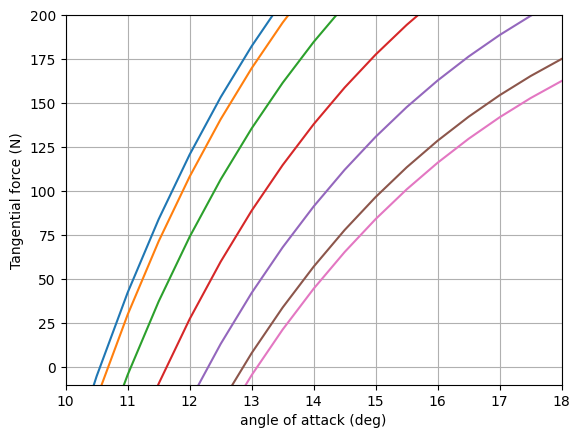

In [ ]:
import matplotlib.pyplot as plt

azimuth = -10
elevation = np.radians(30)
headings = np.radians(np.linspace(-90, 90, 7))
reelout_speed = 1
wind_speed = 4

plt.figure()
for heading in headings:
    # Calculate the tangential force
    ftan = calculate_tangential_force(alpha_curve,cl_curve,cd_curve,azimuth, elevation, reelout_speed, wind_speed, wing_area, mass = mass, heading = heading)
    plt.plot(np.degrees(alpha_curve), ftan, label=f'Wind speed = {wind_speed} m/s')

plt.xlabel('angle of attack (deg)')
plt.ylabel('Tangential force (N)')
plt.grid()
plt.ylim(-10,200)
plt.xlim(10,18)

alpha_trim = alpha_trim_kite
kite_speed = calculate_kite_speed(alpha_trim,azimuth, elevation, reelout_speed, wind_speed, heading)
tether_force = calculate_tether_force(alpha_trim,CL_trim,CD_trim,azimuth, elevation, reelout_speed, wind_speed,kite_speed, wing_area, mass = mass, heading = heading)

print(f'Alpha trim: {np.degrees(alpha_trim)} deg')
print(f'Kite speed: {kite_speed} m/s')
print(f'Tether force: {tether_force} N')

alpha_trim = np.radians(10.5)
print(np.interp(alpha_trim, alpha_curve, clcd))

In [ ]:
# Solve specific condition with weight
azimuth = np.radians(20.0)
elevation = np.radians(55.0)
heading = np.radians(-90)

wind_speed = 8
reelout_speed = 1.4

alpha_trim = find_trim_angle(alpha_curve, 
                            cl_curve,
                            cd_curve,
                            wind_speed=wind_speed,
                            reelout_speed=reelout_speed,
                            azimuth=azimuth,
                            elevation=elevation,
                            mass=mass,
                            wing_area=wing_area,
                            heading=heading)
CL_trim = np.interp(alpha_trim, alpha_curve, cl_curve)
CD_trim = np.interp(alpha_trim, alpha_curve, cd_curve)

kite_speed = calculate_kite_speed(alpha_trim,azimuth, elevation, reelout_speed, wind_speed, heading)
tether_force = calculate_tether_force(alpha_trim,CL_trim,CD_trim,azimuth, elevation, reelout_speed, wind_speed,kite_speed, wing_area, mass = mass, heading = heading)

print(f'Alpha trim: {np.degrees(alpha_trim)} deg')
print(f'Kite speed: {kite_speed} m/s')
print(f'Tether force: {tether_force} N')




Alpha trim: [10.382499] deg
Kite speed: [15.89294968] m/s
Tether force: [2280.39271026] N


Trim angle of attack: [11.62837675] deg


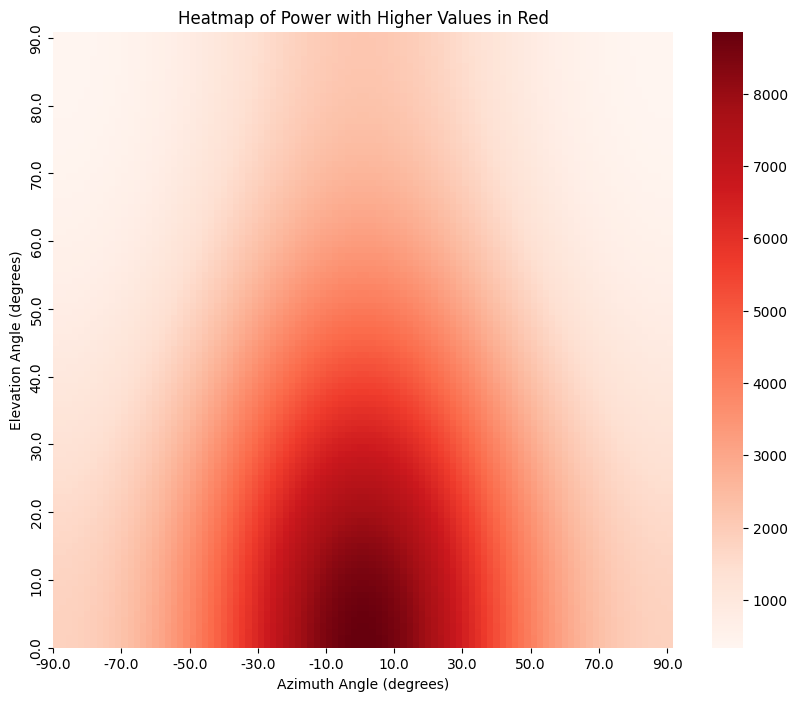

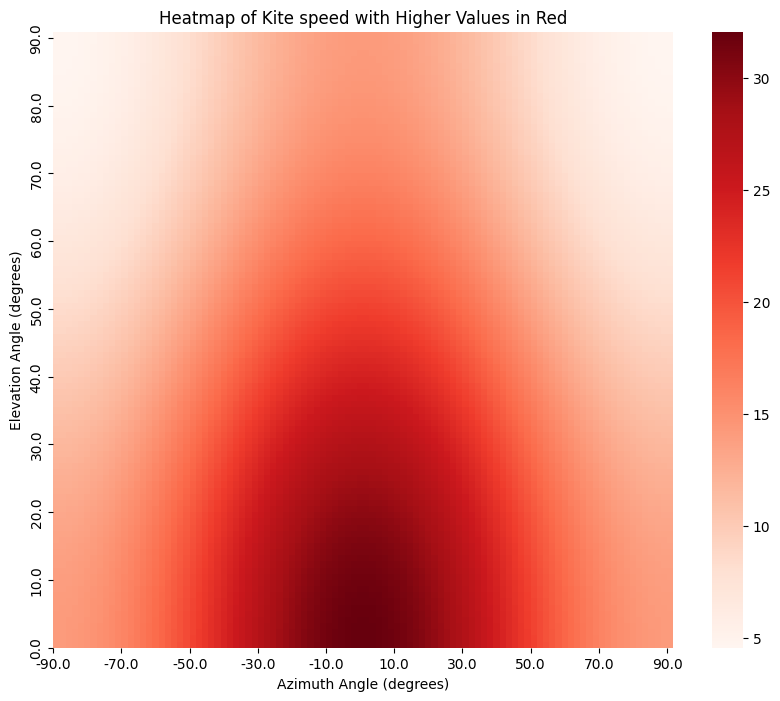

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
## Plot wind window for 0 yaw angle
wind_speed = 8
reelout_speed = 1.4


# Elevation and azimuth angles in radians
elevation_angle = np.linspace(0, 90, 100) * np.pi / 180
azimuth_angle = np.linspace(-90, 90, 100) * np.pi / 180

# Create meshgrid for elevation and azimuth angles
azimuth_grid, elevation_grid = np.meshgrid(azimuth_angle,elevation_angle)

alpha_trim_kite = find_trim_angle(alpha_curve, cl_curve, cd_curve)
print(f'Trim angle of attack: {np.degrees(alpha_trim_kite)} deg')
CL_trim = np.interp(alpha_trim_kite, alpha_curve, cl_curve)
CD_trim = np.interp(alpha_trim_kite, alpha_curve, cd_curve)

kite_speed = calculate_kite_speed(alpha_trim_kite,azimuth_grid, elevation_grid, reelout_speed, wind_speed, heading)
tether_force = calculate_tether_force(alpha_trim_kite,CL_trim,CD_trim,azimuth_grid, elevation_grid, reelout_speed, wind_speed,kite_speed, wing_area, mass = mass, heading = heading)

# Plot the heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(tether_force,cmap="Reds")
# Set the number of ticks
num_ticks = 10
plt.xticks(ticks=np.linspace(0, len(np.sin(azimuth_angle)) - 1, num_ticks), 
           labels=np.round(np.linspace(-90, 90, num_ticks), 1))
plt.yticks(ticks=np.linspace(0, len(np.sin(elevation_angle)) - 1, num_ticks), 
           labels=np.round(np.linspace(0, 90, num_ticks), 1))
# Invert the y-axis
plt.gca().invert_yaxis()

# Customize the plot
plt.title('Heatmap of Power with Higher Values in Red')
plt.xlabel('Azimuth Angle (degrees)')
plt.ylabel('Elevation Angle (degrees)')
plt.show()

# Plot the heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(kite_speed,cmap="Reds")
# Set the number of ticks
num_ticks = 10
plt.xticks(ticks=np.linspace(0, len(np.sin(azimuth_angle)) - 1, num_ticks), 
           labels=np.round(np.linspace(-90, 90, num_ticks), 1))
plt.yticks(ticks=np.linspace(0, len(np.sin(elevation_angle)) - 1, num_ticks), 
           labels=np.round(np.linspace(0, 90, num_ticks), 1))
# Invert the y-axis
plt.gca().invert_yaxis()

# Customize the plot
plt.title('Heatmap of Kite speed with Higher Values in Red')
plt.xlabel('Azimuth Angle (degrees)')
plt.ylabel('Elevation Angle (degrees)')
plt.show()
